# SmartBin Vision — Klasifikasi Sampah Cerdas
**Kelompok 7 | Praktikum AI**

| Peran | Nama | Tugas |
|-------|------|-------|
| Data (EDA & Preprocessing) | Isyana | Download dataset, EDA, augmentasi |
| Model (Training & Evaluasi) | Melati | Arsitektur CNN, training, evaluasi |
| App/Deployment | Tiwy | Streamlit web app |

**Alur:** Download Dataset > EDA > Preprocessing > Modeling > Evaluasi > Export > Web App



## BAGIAN 1 — Download Dataset dari Kaggle
*(Dikerjakan oleh: Isyana — Role: Data)*

Dataset: **garbage-classification-v2** dari Kaggle
- 10 kelas original
- ~6000+ gambar berkualitas tinggi
- Ready untuk training model

In [1]:
# Install opendatasets untuk download dari Kaggle
!pip install opendatasets --quiet

import opendatasets as od

# Download dataset
dataset_url = "https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2"
print("⏳ Downloading dataset... (tunggu beberapa menit)")
od.download(dataset_url)
print("✅ Dataset berhasil di-download!")

⏳ Downloading dataset... (tunggu beberapa menit)
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: melati06
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2


100%|██████████| 1.07G/1.07G [01:00<00:00, 18.8MB/s]



✅ Dataset berhasil di-download!


In [2]:
import os

base = './garbage-classification-v2'
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level <= 2:
        indent = '  ' * level
        print(f'{indent} {os.path.basename(root)}/')

 garbage-classification-v2/
   standardized_256/
     paper/
     plastic/
     clothes/
     glass/
     biological/
     battery/
     trash/
     cardboard/
     shoes/
     metal/
   original/
     paper/
     plastic/
     clothes/
     glass/
     biological/
     battery/
     trash/
     cardboard/
     shoes/
     metal/
   standardized_384/
     paper/
     plastic/
     clothes/
     glass/
     biological/
     battery/
     trash/
     cardboard/
     shoes/
     metal/


## BAGIAN 2 — EDA (Exploratory Data Analysis)
*(Dikerjakan oleh: Isyana — Role Data)*

Dataset **garbage-classification-v2** berisi 10 kelas asli yang akan dipetakan ke **3 kategori SmartBin Vision**.

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

DATASET_PATH = './garbage-classification-v2/standardized_256'

all_classes = sorted(os.listdir(DATASET_PATH))
all_counts  = [len(os.listdir(os.path.join(DATASET_PATH, c))) for c in all_classes]

print('Distribusi data per kelas ASLI:')
for c, n in zip(all_classes, all_counts):
    print(f'  {c:15s}: {n} gambar')
print(f'\nTotal gambar : {sum(all_counts)}')
print(f'Jumlah kelas : {len(all_classes)}')


Distribusi data per kelas ASLI:
  battery        : 756 gambar
  biological     : 699 gambar
  cardboard      : 1411 gambar
  clothes        : 1892 gambar
  glass          : 1736 gambar
  metal          : 930 gambar
  paper          : 1336 gambar
  plastic        : 1597 gambar
  shoes          : 1449 gambar
  trash          : 453 gambar

Total gambar : 12259
Jumlah kelas : 10


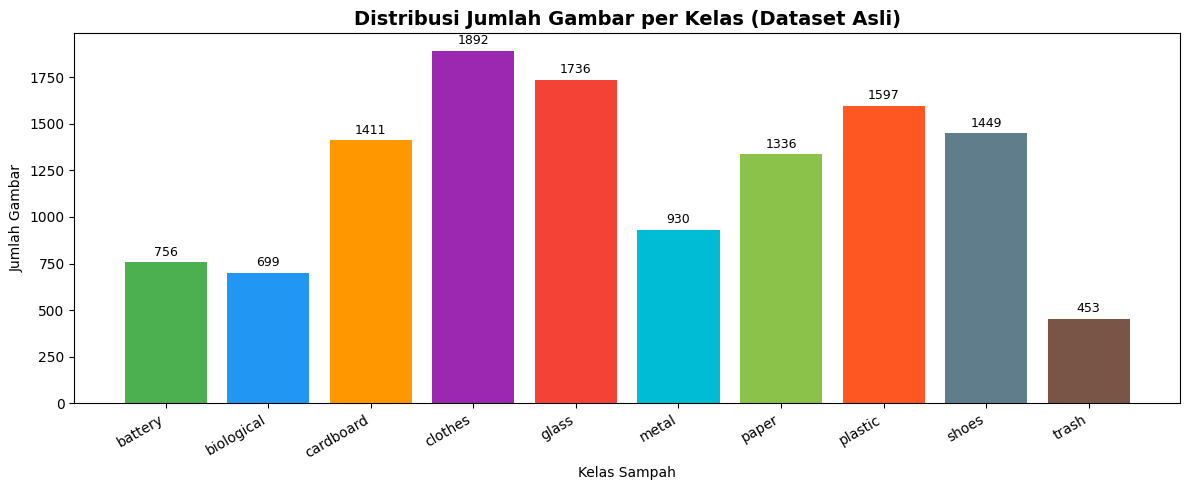

Grafik distribusi kelas tersimpan!


In [4]:
COLORS = [
    '#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336',
    '#00BCD4','#8BC34A','#FF5722','#607D8B','#795548'
]

plt.figure(figsize=(12, 5))
bars = plt.bar(all_classes, all_counts, color=COLORS[:len(all_classes)])
plt.title('Distribusi Jumlah Gambar per Kelas (Dataset Asli)', fontsize=14, fontweight='bold')
plt.xlabel('Kelas Sampah')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=30, ha='right')
for bar, count in zip(bars, all_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('eda_distribusi_kelas.png', dpi=150)
plt.show()
print('Grafik distribusi kelas tersimpan!')


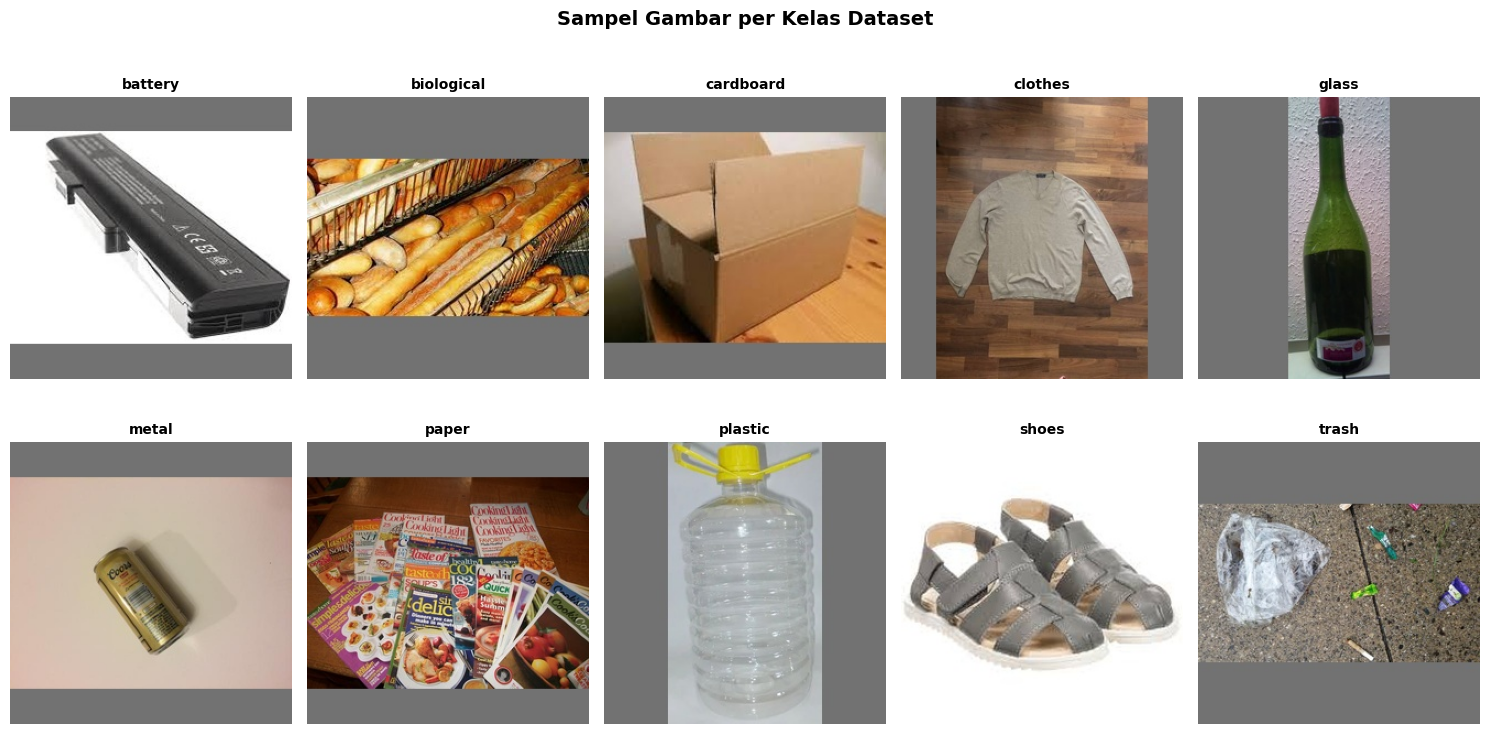

Sampel gambar tiap kelas berhasil ditampilkan!


In [5]:
cols = 5
rows = (len(all_classes) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, cls in enumerate(all_classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10, fontweight='bold')
    axes[i].axis('off')

for j in range(len(all_classes), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sampel Gambar per Kelas Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_sampel_gambar.png', dpi=150)
plt.show()
print('Sampel gambar tiap kelas berhasil ditampilkan!')


In [6]:
from PIL import Image

print('Analisis ukuran gambar per kelas:')
for cls in all_classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    sizes = []
    for fname in os.listdir(cls_path)[:30]:
        img = Image.open(os.path.join(cls_path, fname))
        sizes.append(img.size)
    most_common = Counter(sizes).most_common(1)[0][0]
    print(f'  {cls:15s}: resolusi paling umum = {most_common[0]}x{most_common[1]} px')

print('\nEDA selesai! Semua gambar akan di-resize ke 224x224 untuk model.')


Analisis ukuran gambar per kelas:
  battery        : resolusi paling umum = 256x256 px
  biological     : resolusi paling umum = 256x256 px
  cardboard      : resolusi paling umum = 256x256 px
  clothes        : resolusi paling umum = 256x256 px
  glass          : resolusi paling umum = 256x256 px
  metal          : resolusi paling umum = 256x256 px
  paper          : resolusi paling umum = 256x256 px
  plastic        : resolusi paling umum = 256x256 px
  shoes          : resolusi paling umum = 256x256 px
  trash          : resolusi paling umum = 256x256 px

EDA selesai! Semua gambar akan di-resize ke 224x224 untuk model.


In [7]:
mean_count = np.mean(all_counts)
std_count  = np.std(all_counts)

print('Statistik distribusi kelas:')
print(f'  Rata-rata gambar per kelas : {mean_count:.0f}')
print(f'  Standar deviasi            : {std_count:.0f}')
print(f'  Kelas terbanyak : {all_classes[np.argmax(all_counts)]} ({max(all_counts)} gambar)')
print(f'  Kelas tersedikit: {all_classes[np.argmin(all_counts)]} ({min(all_counts)} gambar)')
print(f'  Rasio imbalance (max/min)  : {max(all_counts)/min(all_counts):.2f}x')

if max(all_counts)/min(all_counts) > 2:
    print('\nDataset cukup imbalanced -> augmentasi diperlukan!')
else:
    print('\nDataset cukup seimbang.')


Statistik distribusi kelas:
  Rata-rata gambar per kelas : 1226
  Standar deviasi            : 461
  Kelas terbanyak : clothes (1892 gambar)
  Kelas tersedikit: trash (453 gambar)
  Rasio imbalance (max/min)  : 4.18x

Dataset cukup imbalanced -> augmentasi diperlukan!


## BAGIAN 3 — Data Preprocessing
*(Dikerjakan oleh: Isyana — Role: Data)*

Pada bagian ini kita akan:
1. **Memetakan 10 kelas asli → 3 kategori SmartBin** (Organik / Anorganik / B3)
2. **Membuat ImageDataGenerator** dengan augmentasi data
3. **Membangun train / val / test split** siap pakai untuk training

In [8]:
# ─── 3.1 Mapping 10 kelas → 3 kategori SmartBin ───────────────────────────
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DATASET_PATH = './garbage-classification-v2/standardized_256'
OUTPUT_PATH  = './smartbin_dataset'   # folder baru hasil remap

# Mapping: kelas asli → kategori SmartBin
CLASS_MAP = {
    'battery'   : 'B3',
    'biological': 'Organik',
    'brown-glass': 'Anorganik',
    'cardboard' : 'Organik',
    'clothes'   : 'Anorganik',
    'green-glass': 'Anorganik',
    'metal'     : 'Anorganik',
    'paper'     : 'Organik',
    'plastic'   : 'Anorganik',
    'trash'     : 'Anorganik',
    'white-glass': 'Anorganik',
}

CATEGORIES = ['Organik', 'Anorganik', 'B3']
COLORS_CAT = {'Organik':'#4CAF50', 'Anorganik':'#2196F3', 'B3':'#F44336'}

print('📌 Mapping 10 kelas → 3 kategori SmartBin:')
for orig, cat in CLASS_MAP.items():
    print(f'  {orig:15s} → {cat}')


📌 Mapping 10 kelas → 3 kategori SmartBin:
  battery         → B3
  biological      → Organik
  brown-glass     → Anorganik
  cardboard       → Organik
  clothes         → Anorganik
  green-glass     → Anorganik
  metal           → Anorganik
  paper           → Organik
  plastic         → Anorganik
  trash           → Anorganik
  white-glass     → Anorganik


In [9]:
# ─── 3.2 Salin & Split gambar ke train / val / test ──────────────────────
from sklearn.model_selection import train_test_split

SEED       = 42
VAL_RATIO  = 0.15
TEST_RATIO = 0.15

random.seed(SEED)
np.random.seed(SEED)

split_counts = {cat: {'train':0,'val':0,'test':0} for cat in CATEGORIES}

for orig_class, category in CLASS_MAP.items():
    src_dir = Path(DATASET_PATH) / orig_class
    if not src_dir.exists():
        print(f'⚠️  Folder tidak ditemukan: {src_dir}')
        continue

    images = [f for f in src_dir.iterdir() if f.suffix.lower() in ('.jpg','.jpeg','.png')]
    random.shuffle(images)

    # Split: train | val | test
    train_imgs, temp = train_test_split(images, test_size=VAL_RATIO+TEST_RATIO, random_state=SEED)
    val_imgs, test_imgs = train_test_split(temp,  test_size=TEST_RATIO/(VAL_RATIO+TEST_RATIO), random_state=SEED)

    for split_name, img_list in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        dest_dir = Path(OUTPUT_PATH) / split_name / category
        dest_dir.mkdir(parents=True, exist_ok=True)
        for img_path in img_list:
            shutil.copy2(img_path, dest_dir / img_path.name)
        split_counts[category][split_name] += len(img_list)

# Ringkasan
print('\n✅ Struktur dataset SmartBin berhasil dibuat!\n')
print(f'{"Kategori":12s} {"Train":>8s} {"Val":>8s} {"Test":>8s} {"Total":>8s}')
print('-'*46)
total_all = 0
for cat in CATEGORIES:
    tr = split_counts[cat]['train']
    va = split_counts[cat]['val']
    te = split_counts[cat]['test']
    tot = tr+va+te
    total_all += tot
    print(f'{cat:12s} {tr:>8d} {va:>8d} {te:>8d} {tot:>8d}')
print('-'*46)
print(f'{"TOTAL":12s} {"":>8s} {"":>8s} {"":>8s} {total_all:>8d}')

⚠️  Folder tidak ditemukan: garbage-classification-v2/standardized_256/brown-glass
⚠️  Folder tidak ditemukan: garbage-classification-v2/standardized_256/green-glass
⚠️  Folder tidak ditemukan: garbage-classification-v2/standardized_256/white-glass

✅ Struktur dataset SmartBin berhasil dibuat!

Kategori        Train      Val     Test    Total
----------------------------------------------
Organik          2411      517      518     3446
Anorganik        3409      731      732     4872
B3                529      113      114      756
----------------------------------------------
TOTAL                                       9074


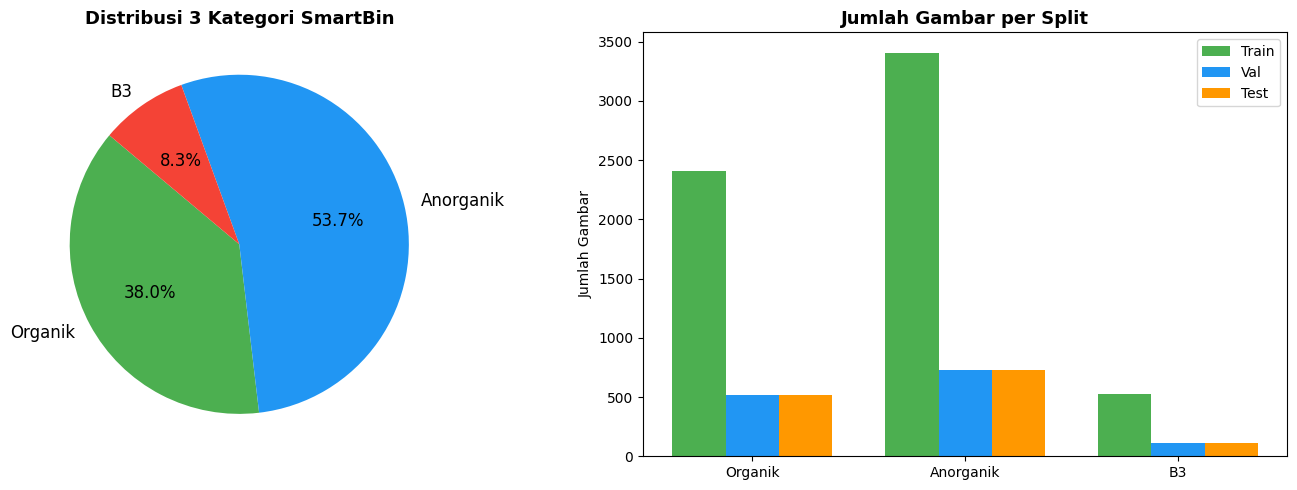

Grafik distribusi preprocessing tersimpan!


In [10]:
# ─── 3.3 Visualisasi distribusi kategori SmartBin ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Pie chart distribusi keseluruhan
totals = {cat: sum(split_counts[cat].values()) for cat in CATEGORIES}
axes[0].pie(
    totals.values(),
    labels=totals.keys(),
    colors=[COLORS_CAT[c] for c in CATEGORIES],
    autopct='%1.1f%%', startangle=140, textprops={'fontsize':12}
)
axes[0].set_title('Distribusi 3 Kategori SmartBin', fontsize=13, fontweight='bold')

# ── Bar chart per split
x = np.arange(len(CATEGORIES))
w = 0.25
bars_train = [split_counts[c]['train'] for c in CATEGORIES]
bars_val   = [split_counts[c]['val']   for c in CATEGORIES]
bars_test  = [split_counts[c]['test']  for c in CATEGORIES]
axes[1].bar(x - w, bars_train, w, label='Train', color='#4CAF50')
axes[1].bar(x,     bars_val,   w, label='Val',   color='#2196F3')
axes[1].bar(x + w, bars_test,  w, label='Test',  color='#FF9800')
axes[1].set_xticks(x)
axes[1].set_xticklabels(CATEGORIES)
axes[1].set_title('Jumlah Gambar per Split', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].legend()

plt.tight_layout()
plt.savefig('preprocessing_distribusi.png', dpi=150)
plt.show()
print('Grafik distribusi preprocessing tersimpan!')


In [11]:
# ─── 3.4 ImageDataGenerator + Augmentasi ─────────────────────────────────
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE  = (224, 224)
BATCH     = 32

# Generator TRAIN → augmentasi agresif
train_gen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 25,
    width_shift_range = 0.15,
    height_shift_range= 0.15,
    shear_range       = 0.12,
    zoom_range        = 0.20,
    horizontal_flip   = True,
    brightness_range  = [0.8, 1.2],
    fill_mode         = 'nearest'
)

# Generator VAL / TEST → hanya rescale
val_test_gen = ImageDataGenerator(rescale=1./255)

train_ds = train_gen.flow_from_directory(
    f'{OUTPUT_PATH}/train',
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_ds = val_test_gen.flow_from_directory(
    f'{OUTPUT_PATH}/val',
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', shuffle=False
)
test_ds = val_test_gen.flow_from_directory(
    f'{OUTPUT_PATH}/test',
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', shuffle=False
)

print('\n📦 Dataset siap!')
print(f'  Class indices : {train_ds.class_indices}')
print(f'  Train batches : {len(train_ds)}')
print(f'  Val   batches : {len(val_ds)}')
print(f'  Test  batches : {len(test_ds)}')


Found 6349 images belonging to 3 classes.
Found 1361 images belonging to 3 classes.
Found 1364 images belonging to 3 classes.

📦 Dataset siap!
  Class indices : {'Anorganik': 0, 'B3': 1, 'Organik': 2}
  Train batches : 199
  Val   batches : 43
  Test  batches : 43


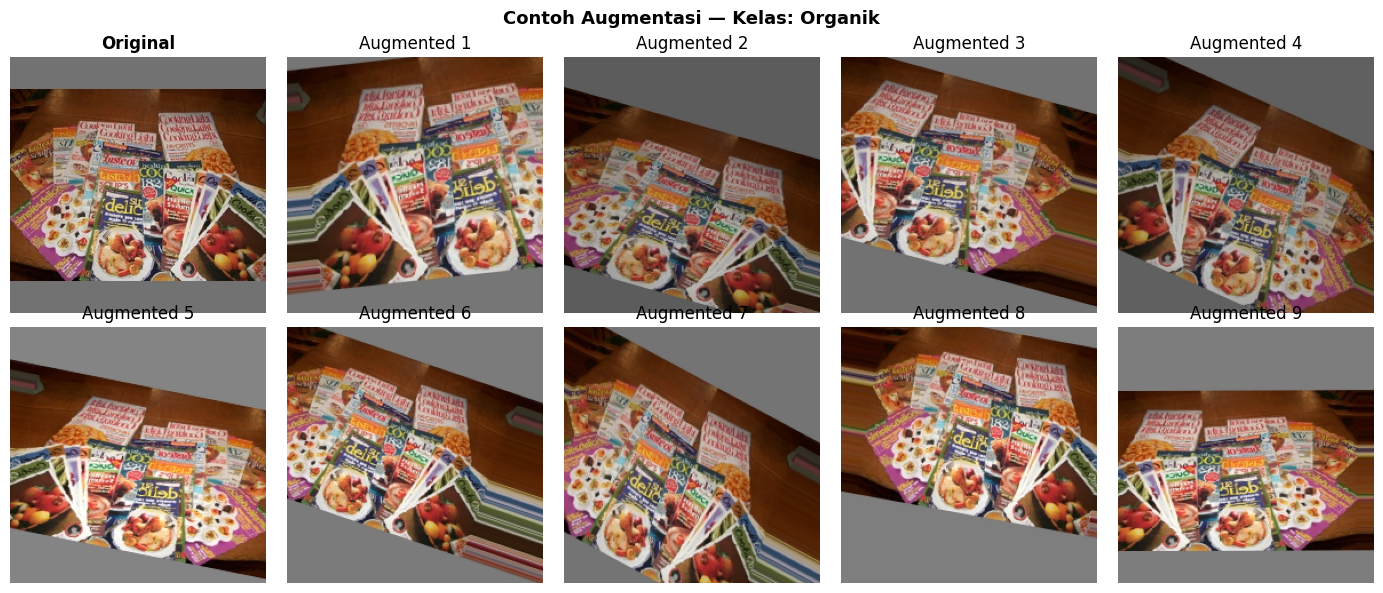

✅ Preprocessing selesai! Data siap diserahkan ke Melati untuk training.


In [12]:
# ─── 3.5 Preview augmentasi pada satu gambar ────────────────────────────
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Ambil satu gambar contoh dari train
sample_cat = CATEGORIES[0]
sample_dir = Path(OUTPUT_PATH) / 'train' / sample_cat
sample_file = list(sample_dir.iterdir())[0]

img_arr = img_to_array(load_img(sample_file, target_size=IMG_SIZE))
img_arr = img_arr.reshape((1,) + img_arr.shape)

aug_gen = ImageDataGenerator(
    rotation_range=25, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.12, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8,1.2], fill_mode='nearest'
)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
axes[0].imshow(img_arr[0].astype('uint8'))
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i, batch in enumerate(aug_gen.flow(img_arr, batch_size=1, seed=SEED), start=1):
    if i >= 10: break
    axes[i].imshow(batch[0].astype('uint8'))
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.suptitle(f'Contoh Augmentasi — Kelas: {sample_cat}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_augmentasi.png', dpi=150)
plt.show()
print('✅ Preprocessing selesai! Data siap diserahkan ke Melati untuk training.')

## BAGIAN 4 — Model: Training & Evaluasi
*(Dikerjakan oleh: Melati — Role: Model)*

Langkah-langkah:
1. Membangun arsitektur **Transfer Learning (MobileNetV2)**
2. Melakukan proses **training** dengan callback (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)
3. **Hyperparameter tuning** via fine-tuning lapisan atas
4. **Evaluasi model** menggunakan Confusion Matrix & Classification Report


In [13]:
# ─── 4.1 Arsitektur Model — Transfer Learning MobileNetV2 ────────────────
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

IMG_SIZE  = (224, 224)
NUM_CLASS = 3
SEED      = 42

# Base model — pretrained ImageNet, tanpa lapisan top
base_model = MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,
    weights     = 'imagenet'
)
base_model.trainable = False   # freeze dulu untuk phase-1

# Tambahkan custom head
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASS, activation='softmax')(x)

model = Model(inputs, outputs, name='SmartBin_MobileNetV2')
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "SmartBin_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [14]:
# ─── 4.2 Compile & Callback ───────────────────────────────────────────────
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('smartbin_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('✅ Model dikompilasi dengan Adam lr=1e-3')
print('📋 Callbacks: EarlyStopping | ReduceLROnPlateau | ModelCheckpoint')

✅ Model dikompilasi dengan Adam lr=1e-3
📋 Callbacks: EarlyStopping | ReduceLROnPlateau | ModelCheckpoint


In [15]:
# ─── 4.3 Phase 1 — Training Head (base frozen) ───────────────────────────
EPOCHS_PHASE1 = 20

print('🚀 Phase 1: Training custom head (base model frozen)...')
history1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS_PHASE1,
    callbacks       = callbacks,
    verbose         = 1
)
print(f'\n✅ Phase 1 selesai! Best val_accuracy: {max(history1.history["val_accuracy"]):.4f}')


🚀 Phase 1: Training custom head (base model frozen)...
Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.7825 - loss: 0.5491
Epoch 1: val_accuracy improved from None to 0.94048, saving model to smartbin_best.h5



Epoch 1: finished saving model to smartbin_best.h5
199/199 ━━━━━━━━━━━━━━━━━━━━ 139s 592ms/step - accuracy: 0.8595 - loss: 0.3721 - val_accuracy: 0.9405 - val_loss: 0.1644 - learning_rate: 0.0010
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9099 - loss: 0.2439
Epoch 2: val_accuracy improved from 0.94048 to 0.95665, saving model to smartbin_best.h5



Epoch 2: finished saving model to smartbin_best.h5
199/199 ━━━━━━━━━━━━━━━━━━━━ 88s 443ms/step - accuracy: 0.9112 - loss: 0.2340 - val_accuracy: 0.9566 - val_loss: 0.1199 - learning_rate: 0.0010
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9157 - loss: 0.2083
Epoch 3: val_accuracy improved from 0.95665 to 0.95738, saving model to smartbin_best.h5



Epoch 3: finished saving model to smartbin_best.h5
199/199 ━━━━━━━━━━━━━━━━━━━━ 87s 438ms/step - accuracy: 0.9223 - loss: 0.1986 - val_accuracy: 0.9574 - val_loss: 0.1159 - learning_rate: 0.0010
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9273 - loss: 0.1888
Epoch 4: val_accuracy improved from 0.95738 to 0.96326, saving model to smartbin_best.h5



Epoch 4: finished saving model to smartbin_best.h5
199/199 ━━━━━━━━━━━━━━━━━━━━ 88s 441ms/step - accuracy: 0.9351 - loss: 0.1787 - val_accuracy: 0.9633 - val_loss: 0.1133 - learning_rate: 0.0010
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9462 - loss: 0.1468
Epoch 5: val_accuracy did not improve from 0.96326
199/199 ━━━━━━━━━━━━━━━━━━━━ 88s 440ms/step - accuracy: 0.9428 - loss: 0.1511 - val_accuracy: 0.9589 - val_loss: 0.1155 - learning_rate: 0.0010
Epoch 6/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9511 - loss: 0.1366
Epoch 6: val_accuracy did not improve from 0.96326
199/199 ━━━━━━━━━━━━━━━━━━━━ 89s 449ms/step - accuracy: 0.9480 - loss: 0.1441 - val_accuracy: 0.9611 - val_loss: 0.1109 - learning_rate: 0.0010
Epoch 7/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9428 - loss: 0.1517
Epoch 7: val_accuracy did not improve from 0.96326
199/199 ━━━━━━━━━━━━━━━━━━━━ 89s 445ms/step - accuracy: 0.9457 - loss: 0.1404 - val_accuracy: 0.958


Epoch 13: finished saving model to smartbin_best.h5
199/199 ━━━━━━━━━━━━━━━━━━━━ 87s 437ms/step - accuracy: 0.9631 - loss: 0.0965 - val_accuracy: 0.9655 - val_loss: 0.1024 - learning_rate: 5.0000e-04
Epoch 14/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9703 - loss: 0.0843
Epoch 14: val_accuracy did not improve from 0.96547
199/199 ━━━━━━━━━━━━━━━━━━━━ 89s 445ms/step - accuracy: 0.9698 - loss: 0.0823 - val_accuracy: 0.9625 - val_loss: 0.1053 - learning_rate: 5.0000e-04
Epoch 15/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9737 - loss: 0.0742
Epoch 15: val_accuracy did not improve from 0.96547
199/199 ━━━━━━━━━━━━━━━━━━━━ 87s 435ms/step - accuracy: 0.9685 - loss: 0.0884 - val_accuracy: 0.9603 - val_loss: 0.1097 - learning_rate: 5.0000e-04
Epoch 16/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9666 - loss: 0.0857
Epoch 16: val_accuracy did not improve from 0.96547
199/199 ━━━━━━━━━━━━━━━━━━━━ 86s 429ms/step - accuracy: 0.9666 - loss: 0.0863 - 


Epoch 17: finished saving model to smartbin_best.h5
199/199 ━━━━━━━━━━━━━━━━━━━━ 90s 452ms/step - accuracy: 0.9734 - loss: 0.0750 - val_accuracy: 0.9669 - val_loss: 0.1180 - learning_rate: 5.0000e-04
Epoch 18/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9736 - loss: 0.0733
Epoch 18: val_accuracy did not improve from 0.96694
199/199 ━━━━━━━━━━━━━━━━━━━━ 87s 434ms/step - accuracy: 0.9734 - loss: 0.0733 - val_accuracy: 0.9647 - val_loss: 0.1103 - learning_rate: 2.5000e-04
Epoch 19/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9732 - loss: 0.0734
Epoch 19: val_accuracy did not improve from 0.96694
199/199 ━━━━━━━━━━━━━━━━━━━━ 86s 432ms/step - accuracy: 0.9740 - loss: 0.0696 - val_accuracy: 0.9662 - val_loss: 0.1183 - learning_rate: 2.5000e-04
Epoch 20/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9775 - loss: 0.0650
Epoch 20: val_accuracy did not improve from 0.96694
199/199 ━━━━━━━━━━━━━━━━━━━━ 86s 433ms/step - accuracy: 0.9768 - loss: 0.0666 - 

In [16]:
# ─── 4.4 Phase 2 — Fine-tuning (unfreeze top 30 layer base) ──────────────
# Unfreeze 30 layer terakhir base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Re-compile dengan LR lebih kecil
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

EPOCHS_PHASE2 = 20
INITIAL_EPOCH = len(history1.history['loss'])

print('🔧 Phase 2: Fine-tuning 30 layer terakhir base model...')
history2 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = INITIAL_EPOCH + EPOCHS_PHASE2,
    initial_epoch   = INITIAL_EPOCH,
    callbacks       = callbacks,
    verbose         = 1
)
print(f'\n✅ Phase 2 selesai! Best val_accuracy: {max(history2.history["val_accuracy"]):.4f}')

🔧 Phase 2: Fine-tuning 30 layer terakhir base model...
Epoch 21/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.9183 - loss: 0.2005
Epoch 21: val_accuracy did not improve from 0.96694
199/199 ━━━━━━━━━━━━━━━━━━━━ 121s 515ms/step - accuracy: 0.9287 - loss: 0.1790 - val_accuracy: 0.9544 - val_loss: 0.1188 - learning_rate: 1.0000e-05
Epoch 22/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9449 - loss: 0.1453
Epoch 22: val_accuracy did not improve from 0.96694
199/199 ━━━━━━━━━━━━━━━━━━━━ 87s 440ms/step - accuracy: 0.9479 - loss: 0.1366 - val_accuracy: 0.9596 - val_loss: 0.1196 - learning_rate: 1.0000e-05
Epoch 23/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9424 - loss: 0.1513
Epoch 23: val_accuracy did not improve from 0.96694
199/199 ━━━━━━━━━━━━━━━━━━━━ 86s 435ms/step - accuracy: 0.9430 - loss: 0.1464 - val_accuracy: 0.9611 - val_loss: 0.1129 - learning_rate: 1.0000e-05
Epoch 24/40
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9487 - l

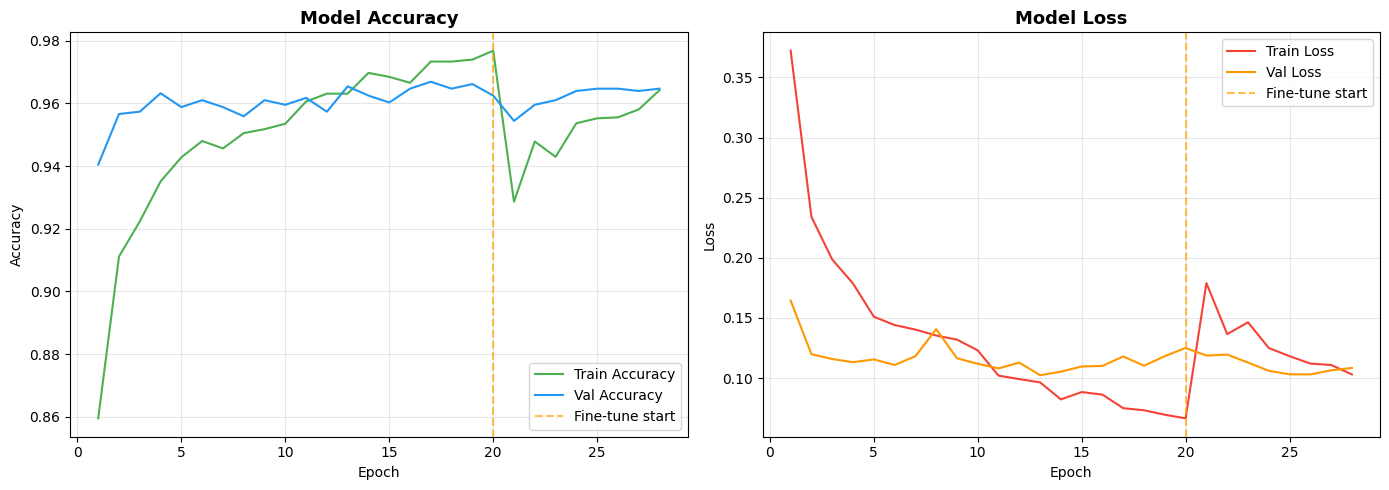

Grafik training history tersimpan!


In [17]:
# ─── 4.5 Plot Training History ────────────────────────────────────────────
import matplotlib.pyplot as plt

def combine_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

hist = combine_history(history1, history2)
epochs_range = range(1, len(hist['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epochs_range, hist['accuracy'],     label='Train Accuracy', color='#4CAF50')
axes[0].plot(epochs_range, hist['val_accuracy'], label='Val Accuracy',   color='#2196F3')
axes[0].axvline(x=len(history1.history['loss']), color='orange', linestyle='--', alpha=0.7, label='Fine-tune start')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(epochs_range, hist['loss'],     label='Train Loss', color='#F44336')
axes[1].plot(epochs_range, hist['val_loss'], label='Val Loss',   color='#FF9800')
axes[1].axvline(x=len(history1.history['loss']), color='orange', linestyle='--', alpha=0.7, label='Fine-tune start')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_training_history.png', dpi=150)
plt.show()
print('Grafik training history tersimpan!')

43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 334ms/step

📊 Classification Report:
              precision    recall  f1-score   support

   Anorganik       0.96      0.98      0.97       732
          B3       0.96      0.96      0.96       114
     Organik       0.97      0.94      0.96       518

    accuracy                           0.96      1364
   macro avg       0.96      0.96      0.96      1364
weighted avg       0.96      0.96      0.96      1364



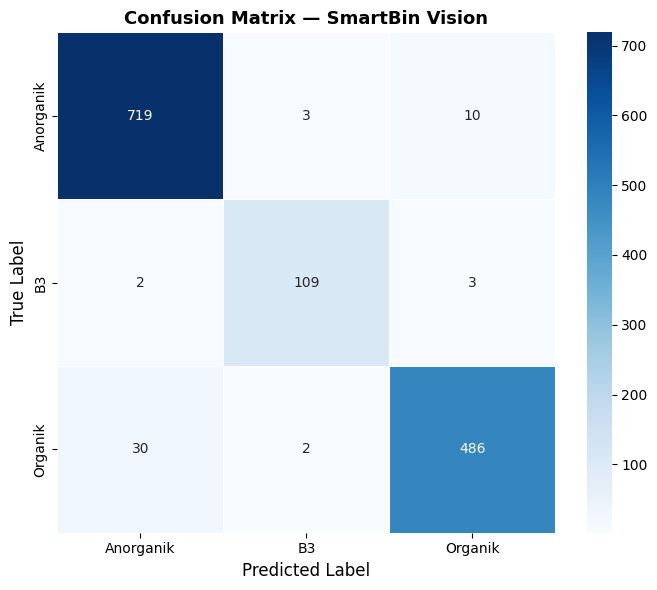

Confusion matrix tersimpan!

✅ Test Accuracy : 0.9633 (96.33%)
   Test Loss    : 0.1358


In [21]:
# ─── 4.6 Evaluasi pada Test Set ──────────────────────────────────────────
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf # <--- Tambahkan import tensorflow jika belum

# Load best model (Memuat arsitektur sekaligus bobotnya secara otomatis)
model = tf.keras.models.load_model('smartbin_best.h5') # <--- UBAH BARIS INI

# Predict
test_ds.reset()
y_pred_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_ds.classes

CLASS_NAMES = list(test_ds.class_indices.keys())

# ── Classification Report
print('\n📊 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ── Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — SmartBin Vision', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix tersimpan!')

# Accuracy keseluruhan
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'\n✅ Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'   Test Loss    : {test_loss:.4f}')

In [22]:
# ─── 4.7 Export Model (.h5 & TFLite) ─────────────────────────────────────
import os

# Simpan sebagai .h5
model.save('smartbin_model.h5')
print('✅ Model disimpan: smartbin_model.h5')
print(f'   Ukuran file : {os.path.getsize("smartbin_model.h5") / 1e6:.1f} MB')

# Konversi ke TFLite (lebih ringan untuk deployment)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantization
tflite_model = converter.convert()

with open('smartbin_model.tflite', 'wb') as f:
    f.write(tflite_model)
print(f'\n✅ TFLite model disimpan: smartbin_model.tflite')
print(f'   Ukuran file : {os.path.getsize("smartbin_model.tflite") / 1e6:.1f} MB')

# Simpan label mapping
import json
label_map = {v: k for k, v in test_ds.class_indices.items()}
with open('label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print('\n✅ Label map disimpan: class_names.json')
print(f'   Labels: {label_map}')
print('\n🎉 Model siap diserahkan ke Tiwy untuk deployment!')


✅ Model disimpan: smartbin_model.h5
   Ukuran file : 10.9 MB
Saved artifact at '/tmp/tmpuo4wsm8f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132899219346384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132899219347344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132899219347152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132899219346768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132899219347920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132899219345808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132899219347536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132899219347728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132899219344848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132899219348880: Tenso

In [23]:
%%writefile app.py
from flask import Flask, request, jsonify, render_template
import tensorflow as tf
from PIL import Image
import numpy as np
import json
import os

app = Flask(__name__)

# Load model dan metadata kelas yang disesuaikan
MODEL_PATH = 'smartbin_model.h5'
LABEL_PATH = 'class_names.json'

model = tf.keras.models.load_model(MODEL_PATH)

with open(LABEL_PATH, 'r') as f:
    class_info = json.load(f)

# Mengambil ukuran resolusi input gambar langsung dari file json
IMG_SIZE = tuple(class_info.get('model_input_size', [150, 150]))

def prepare_image(image, target_size):
    if image.mode != "RGB":
        image = image.convert("RGB")
    image = image.resize(target_size)
    image = np.array(image) / 255.0  # Normalisasi gambar
    image = np.expand_dims(image, axis=0)
    return image

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    if 'image' not in request.files:
        return jsonify({'error': 'Tidak ada file gambar yang dikirim'}), 400

    file = request.files['image']
    try:
        image = Image.open(file.stream)
        processed_image = prepare_image(image, IMG_SIZE)

        # Prediksi gambar menggunakan model h5
        predictions = model.predict(processed_image)
        class_idx = np.argmax(predictions[0])
        confidence = float(np.max(predictions[0]))

        # Mengambil nama teks kelas berdasarkan indeksnya dari struktur class_names.json
        result_label = class_info['classes'][class_idx]

        return jsonify({
            'class_index': int(class_idx),
            'label': result_label,
            'confidence': confidence
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

if __name__ == '__main__':
    app.run(debug=True, port=5000)

Writing app.py


In [24]:
model.save('smartbin_model.h5')

class_info = {
    'classes'          : list(train_ds.class_indices.keys()),
    'class_indices'    : train_ds.class_indices,
    'model_input_size' : list(IMG_SIZE)
}
with open('class_names.json', 'w') as f:
    json.dump(class_info, f, indent=2)

# + TFLite export

print('File untuk Web App (Tiwy):')
print('  1. smartbin_model.h5')
print('  2. class_names.json')
print('  3. app.py  (dibuat di Bagian 5)')


File untuk Web App (Tiwy):
  1. smartbin_model.h5
  2. class_names.json
  3. app.py  (dibuat di Bagian 5)
